**Task 3**
1. Data Understanding & Cleaning
    *   Describe the dataset and variables
    *   Handle missing or inconsistent values (if any)
2. Exploratory Data Analysis (EDA)
    *   Identify key factors affecƟng sales
    *   Analyze relaƟonships between price, quanƟty, discount, and sales

3. Model Development
    *   Define independent (X) and dependent (y) variables
    *   Perform train–test split (70–30 or 80–20)
    *   Implement:
        *   Simple Linear Regression
        *   MulƟple Linear Regression
    *   Calculate and explain:
        *   Mean Absolute Error (MAE)
        *   Mean Squared Error (MSE)
        *   Root Mean Squared Error (RMSE)
        *   R2 Score
5. InterpretaƟon & Insights
    *   Interpret regression coefficients
    *   IdenƟfy which variables most impact sales
    *   Discuss overfiƫng vs underfiƫng (I’ll add one more document on
this concept)

In [2]:
#Upload file in Google Colab
from google.colab import files
uploaded = files.upload()

Saving supermarket_sales_california.xlsx to supermarket_sales_california.xlsx


In [3]:
#Import liberaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Load the data
df = pd.read_excel(list(uploaded.keys())[0])
df.head(10)

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Category,Unit_Price,Quantity,Discount,Rating,Discount_Amount,Net_Sales,Tax_7_25_percent,Total_Sales
0,INV200000,West-3,San Diego,Normal,Female,Clothing,319.91,4,0.26,4.5,332.71,946.93,68.65,1015.58
1,INV200001,West-1,Sacramento,Normal,Female,Food,569.62,7,0.24,1.8,956.96,3030.38,219.70,3250.08
2,INV200002,West-3,San Diego,Member,Female,Food,48.57,6,0.34,6.1,99.08,192.34,13.94,206.28
3,INV200003,West-3,Oakland,Member,Male,Clothing,361.92,15,0.18,4.3,977.18,4451.62,322.74,4774.36
4,INV200004,West-1,Anaheim,Member,Male,Electronics,318.27,6,0.19,2.8,362.83,1546.79,112.14,1658.93
5,INV200005,West-1,Fresno,Member,Female,Food,312.16,7,0.09,6.4,196.66,1988.46,144.16,2132.62
6,INV200006,West-3,Irvine,Member,Female,Clothing,524.53,3,0.13,4.3,204.57,1369.02,99.25,1468.27
7,INV200007,West-2,Los Angeles,Normal,Male,Home Appliances,127.30,13,0.01,2.5,16.55,1638.35,118.78,1757.13
8,INV200008,West-3,Oakland,Member,Male,Cosmetics,29.26,2,0.24,7.3,14.04,44.48,3.22,47.70
9,INV200009,West-3,San Diego,Member,Male,Food,405.00,3,0.11,8.5,133.65,1081.35,78.40,1159.75


Step 1: Data Understanding & Cleaning

In [5]:
#Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Invoice_ID        5000 non-null   object 
 1   Branch            5000 non-null   object 
 2   City              5000 non-null   object 
 3   Customer_Type     5000 non-null   object 
 4   Gender            5000 non-null   object 
 5   Product_Category  5000 non-null   object 
 6   Unit_Price        5000 non-null   float64
 7   Quantity          5000 non-null   int64  
 8   Discount          5000 non-null   float64
 9   Rating            5000 non-null   float64
 10  Discount_Amount   5000 non-null   float64
 11  Net_Sales         5000 non-null   float64
 12  Tax_7_25_percent  5000 non-null   float64
 13  Total_Sales       5000 non-null   float64
dtypes: float64(7), int64(1), object(6)
memory usage: 547.0+ KB


In [6]:
#check missing values in each column
df.isnull().sum()

,0
Invoice_ID,0
Branch,0
City,0
Customer_Type,0
Gender,0
Product_Category,0
Unit_Price,0
Quantity,0
Discount,0
Rating,0


In [7]:
#Statistics analysis
df.describe().round(4)

,Unit_Price,Quantity,Discount,Rating,Discount_Amount,Net_Sales,Tax_7_25_percent,Total_Sales
count,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000,5000.0000
mean,308.7607,10.0684,0.1779,5.4486,551.1243,2537.9263,183.9997,2721.9260
std,170.6289,5.4222,0.1004,2.6018,603.3678,2140.3556,155.1759,2295.5314
min,5.1500,1.0000,0.0000,1.0000,0.0000,3.5400,0.2600,3.8000
25%,165.2175,5.0000,0.0900,3.2000,106.3700,805.2975,58.3850,863.6825
50%,311.5550,10.0000,0.1800,5.5000,340.6800,1966.7950,142.5950,2109.3900
75%,452.8750,15.0000,0.2600,7.7000,785.4375,3766.1075,273.0425,4039.1500
max,599.9400,19.0000,0.3500,10.0000,3820.3100,10676.8800,774.0700,11450.9500


In [8]:
#Remove Duplicates
df.drop_duplicates(inplace= True)

In [9]:
#Fill missing numeric values with the mean; since no nulls exist (verified earlier in cell 9), this step has no impact and is for understanding only.
df.fillna(df.mean(numeric_only= True), inplace= True)

Step 2: Exploratory Data Analysis (EDA)

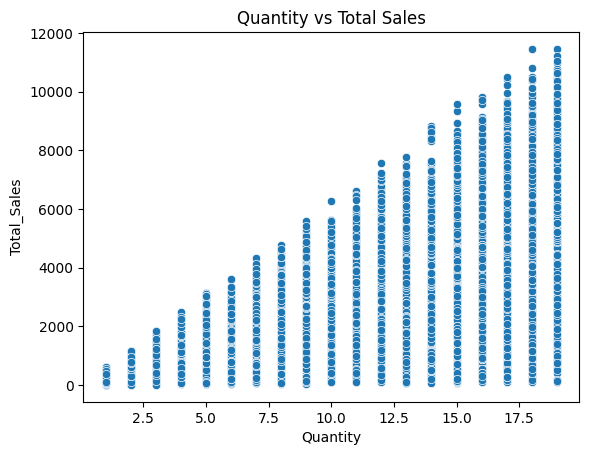

In [10]:
#Relationship between Quanity and total Sales
sns.scatterplot(x= 'Quantity', y= 'Total_Sales', data= df)
plt.title("Quantity vs Total Sales")
plt.show()

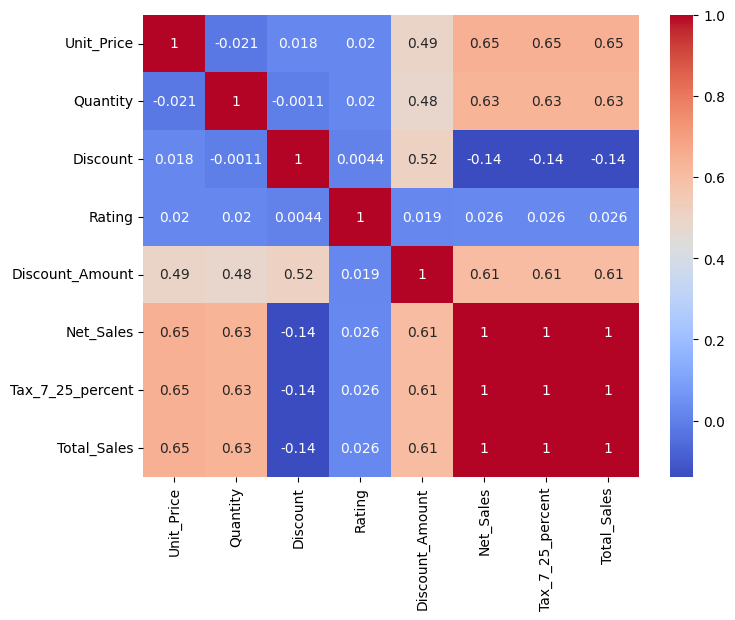

In [11]:
#Correlation Heatmap (Numerical Features)  (from reference file)

plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include= np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

Heatmap explaination:

1. Total_Sales correlations
    
    
    Strong positive correlation with

        Net_Sales (1.0) → makes sense, Total_Sales includes Net_Sales

        Tax_7_25_percent (1.0) → tax is directly proportional to sales

        Quantity (~0.63) → selling more units increases sales

        Unit_Price (~0.65) → expensive products increase sales
    
    Weak negative correlation with:
      
        Discount (~-0.14) → bigger discounts slightly reduce revenue per invoice

2. Other strong correlations

        Net_Sales, Tax, and Total_Sales are basically very strongly correlated (1.0)

        Discount_Amount correlates moderately with Quantity and Unit_Price (0.48–0.49)

3. Low impact variables

    Rating has almost no correlation with Total_Sales (~0.026) →
      
        customer rating doesn’t affect invoice amount directly

Step 3: Model Development

In [12]:
#Define independent (X) and dependent (y) variables
x = df[["Unit_Price", "Quantity", "Discount"]]
y = df["Total_Sales"]

In [13]:
#Perform train–test split (70–30 or 80–20)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.20, random_state= 42)

In [14]:
#Implement: Simple Linear Regression
model = LinearRegression() #build linear regression model
model.fit(x_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(x_test) #make predction

In [16]:
#Implement: Multiple Linear Regression
multi_model = LinearRegression()
multi_model.fit(x_train, y_train)

LinearRegression()

In [17]:
y_multi_pred= multi_model.predict(x_test) #make prediction

In [18]:
#Calculate and explain for Simple Linear Regression Metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE) and R2 Score
#Evaluate Model Performance
print("Simple Linear Regression")
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score: ", r2_score(y_test, y_pred))

Simple Linear Regression
MAE:  659.7072617630063
MSE:  794603.8984905048
RMSE:  891.4055746350842
R2 Score:  0.8414514391424115


In [19]:
#Calculate and explain for Multiple Linear Regression Metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE) and R2 Score
print("Multiple Linear Regression")
print("MAE: ", mean_absolute_error(y_test, y_multi_pred))
print("MSE: ", mean_squared_error(y_test, y_multi_pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, y_multi_pred)))
print("R2 Score: ", r2_score(y_test, y_multi_pred))

Multiple Linear Regression
MAE:  659.7072617630063
MSE:  794603.8984905048
RMSE:  891.4055746350842
R2 Score:  0.8414514391424115


As it is Multiple Linear Regression because X_train contains more than one independent variable, so we will consider only Multiple linear regression.

Step 4: Interpretation & Insights

In [20]:
#Interpret regression coefficients
coeff_df= pd.DataFrame(
    {
        "Feature": x.columns,
        "Coefficient": multi_model.coef_
    }
)
coeff_df.sort_values(by= "Coefficient", ascending= False)

,Feature,Coefficient
1,Quantity,274.254986
0,Unit_Price,8.984172
2,Discount,-3495.614284


Coefficient Interpretation:
*   Qualtity: If qualtity is increase by 1 unit then total_sales increases by $288.439

    So, selling more items increase revenue.
*   Unit_price: if unit price is increase by 1 dollar, total sales increases by 9.39$.

    So, Highly priced products raise total salesvalues but impact is less than Qualtity.
*   Discount: is discount amount is increased by 1 dollar, total sales decreases by $0.26.
    
    So, it shoukd be suggested that discount should be used carefully as this will reduce profits.   

Quantity has most impact on total sales.

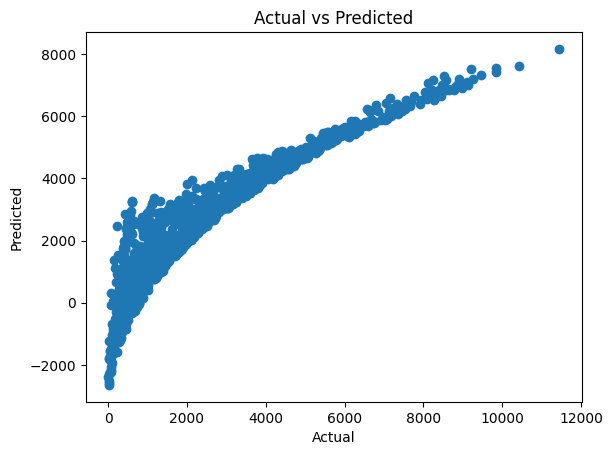

In [21]:
#Actual and predicted plot
plt.scatter(y_test, y_multi_pred)
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

This plot explains that how close predictions are to real sales. Tells if the model is working fine.

overfitting vs underfitting:

Overfitting happens when the model learns too much from the training data, including noise and outliers. It performs very well on training data but poorly on test data. Overfitting happens due to:

*   Model too complex
*   Too many features
*   Very little data
*   No regularization
*   High variance

Underfitting happens when the model fails to learn important patterns. It performs poorly on both training and testing data. Underfitting happens due to:

*   Model is too simple
*   Very high regularization
*   Features are weak or missing
*   Not enough training
*   High bias

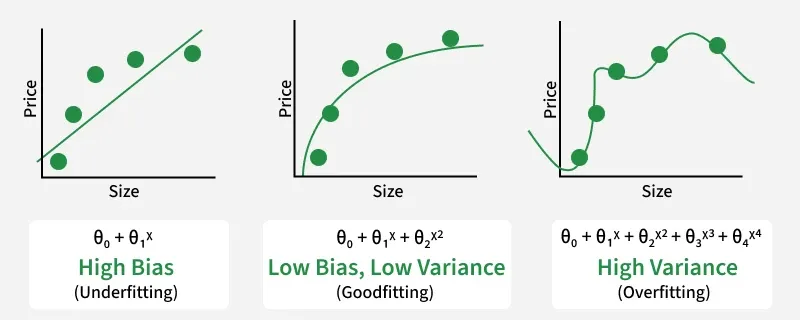![image.png]()